In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
logistic = pd.read_csv("logistic_regression.csv")
svm = pd.read_csv("svm.csv")
rf = pd.read_csv("random_forest.csv")
dt = pd.read_csv("decision_tree_results.csv")

In [46]:
results = pd.DataFrame({
    "Model": [
        logistic["Algorithm"][0],
        svm["Algorithm"][0],
        rf["Algorithm"][0],
        dt["Algorithm"][0]
    ],
    "Accuracy": [
        logistic["Accuracy"][0],
        svm["Accuracy"][0],
        rf["Accuracy"][0],
        dt["Test Accuracy"][0]   
    ]
})

In [47]:
print(results)

                 Model  Accuracy
0  Logistic Regression  0.723846
1                  SVM  0.780769
2        Random Forest  0.825385
3        Decision Tree  0.770000


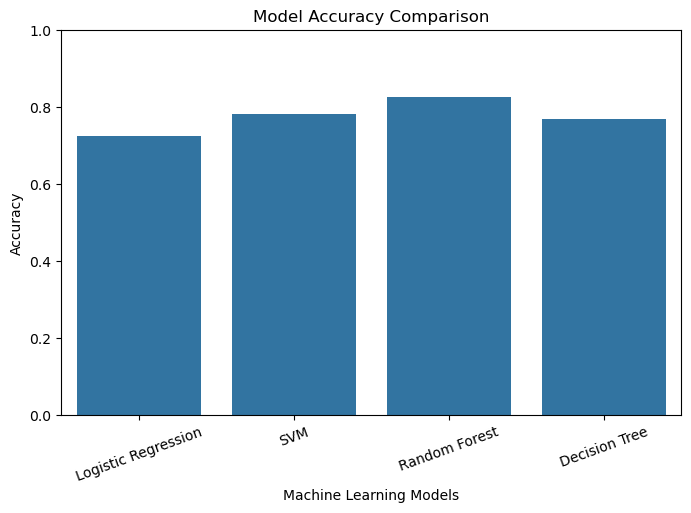

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

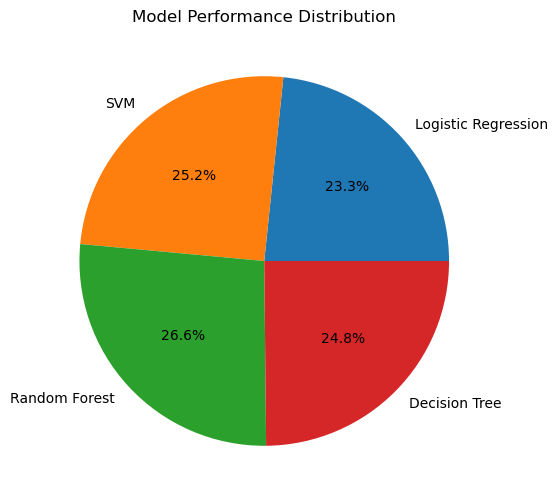

In [49]:
plt.figure(figsize=(6,6))
plt.pie(results["Accuracy"], labels=results["Model"], autopct='%1.1f%%')
plt.title("Model Performance Distribution")
plt.show()

In [50]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
Accuracy         0.825385
Name: 2, dtype: object


In [51]:
print("\nFINAL ANALYSIS")
print("-------------------------")

print("1. Ensemble methods perform better than linear models.")
print("2. SVM improves accuracy using non-linear kernel (RBF).")
print("3. Logistic Regression is simple but less powerful.")
print("4. Random Forest gives best performance due to feature sampling and multiple trees.")

print("\nConclusion:")
print("Random Forest is the best model for wine quality prediction in this project.")


FINAL ANALYSIS
-------------------------
1. Ensemble methods perform better than linear models.
2. SVM improves accuracy using non-linear kernel (RBF).
3. Logistic Regression is simple but less powerful.
4. Random Forest gives best performance due to feature sampling and multiple trees.

Conclusion:
Random Forest is the best model for wine quality prediction in this project.


In [52]:
import joblib
import numpy as np

In [53]:
rf_model = joblib.load("rf_model.pkl")

In [54]:
best_model = rf_model

In [55]:
scaler = joblib.load("scaler.pkl")

In [56]:
user_input = []

for f in feature_names:
    value = float(input(f"{f}: "))
    user_input.append(value)

fixed acidity:  2.1
volatile acidity:  2.1
citric acid:  3.2
residual sugar:  4.3
chlorides:  2.3
free sulfur dioxide:  1.2
total sulfur dioxide:  4.3
density:  2.1
pH:  4.3
sulphates:  2.1
alcohol:  3.2


In [57]:
user_input_df = pd.DataFrame([user_input], columns=feature_names)
user_input_scaled = scaler.transform(user_input_df)

In [58]:
prediction = best_model.predict(user_input_scaled)

In [59]:
print("\n" + "="*40)
print("🍷  WINE QUALITY PREDICTION RESULT  🍷")
print("="*40)

if prediction[0] == 1:
    print("\n✅ STATUS : GOOD WINE")
    print("🌟 This wine meets quality standards.")
    print("👍 Suitable for consumption and sale.")
else:
    print("\n❌ STATUS : BAD WINE")
    print("⚠️ This wine does not meet quality standards.")
    print("👎 Improvement in composition is needed.")

print("="*40)


🍷  WINE QUALITY PREDICTION RESULT  🍷

✅ STATUS : GOOD WINE
🌟 This wine meets quality standards.
👍 Suitable for consumption and sale.
